# 1D Nonlinear Heat Conduction via Physics-Informed Neural Networks (PINNs)

This model uses a Neural Network to solve the 1D steady-state heat conduction equation. Unlike standard neural networks that rely only on data, a **PINN** uses the underlying physical laws (differential equations) as a loss function to guide the learning process.

---

## 1. The Physics Loss (PDE Residual)
The governing equation for 1D steady-state conduction (with no internal heat generation) is:

$$\frac{d}{dx} \left[ k(T) \frac{dT}{dx} \right] = 0$$

In this problem, the thermal conductivity $k$ is **nonlinear** and depends on temperature:

$$k(T) = k_0(1 + \beta T)$$

### How it works in code:
The PINN minimizes a **Physics Loss** ($\mathcal{L}_{physics}$), which is the residual of the differential equation. We use `jax.grad` to compute the derivatives of the network's predictions.

$$\mathcal{L}_{physics} = \text{MSE} \left( \frac{d}{dx} \left[ k(T_{pred}) \frac{dT_{pred}}{dx} \right] \right)$$

If the network perfectly obeys the laws of physics, this term will be zero.

---

## 2. The Boundary Loss (Data Constraints)
The physics equation describes the *shape* of the heat flow, but the **Boundary Conditions (BCs)** define the specific scenario. We use Dirichlet boundaries at the ends of the rod:
* **Left End ($x=0$):** $T = T_{left}$
* **Right End ($x=L$):** $T = T_{right}$

The **Boundary Loss** ($\mathcal{L}_{BC}$) ensures the network matches these fixed values:

$$\mathcal{L}_{BC} = [T_{pred}(0) - T_{left}]^2 + [T_{pred}(L) - T_{right}]^2$$

**Total Loss:** The optimizer minimizes $W_1 \cdot \mathcal{L}_{BC} + W_2 \cdot \mathcal{L}_{physics}$.

---

## 3. Derivation of the Analytical Solution
To verify the PINN, we derive the exact solution for the case where $T(0) = 0$ and $T(L) = T_R$.

### Step 1: Integration
Integrating $\frac{d}{dx} [k(T) \frac{dT}{dx}] = 0$ once gives:

$$k_0(1 + \beta T) \frac{dT}{dx} = C_1$$

### Step 2: Separation of Variables
Integrating a second time with respect to $x$:

$$k_0 \left( T + \frac{1}{2}\beta T^2 \right) = C_1 x + C_2$$

### Step 3: Applying Boundary Conditions
* At $x=0, T=0 \implies \mathbf{C_2 = 0}$.
* At $x=L, T=T_R \implies C_1 = \frac{k_0(T_R + 0.5\beta T_R^2)}{L}$.

### Step 4: Solving for T(x)
Substituting the constants back and solving the quadratic equation for $T$:

$$T(x) = \frac{-1 + \sqrt{1 + 2\beta M(x)}}{\beta}$$

Where $M(x) = \frac{(T_R + 0.5\beta T_R^2)}{L}x$.

This analytical curve is used in the final plot to check if the PINN successfully "learned" the correct physical behavior.

# PINN with Hard Boundary Constraints (BCs)

In standard PINNs, boundary conditions are treated as "Soft Constraints" (part of the loss function). However, this can lead to inaccuracies at the boundaries if the weights are not perfectly balanced. This implementation uses a **Hard Constraint** transformation.

---

## 1. The Transformation Strategy
We define the predicted temperature $T_{pred}(x)$ using a mathematical structure that automatically satisfies $T(0) = T_L$ and $T(L) = T_R$, regardless of the neural network's weights.

The formula used is:

$$T_{pred}(x) = \underbrace{A(x)}_{\text{Boundary Term}} + \underbrace{B(x)}_{\text{Shaping Function}} \cdot \text{NN}(x)$$

### Breakdown of the Terms:
1. **Boundary Term ($A(x)$):** A simple linear interpolator between the two boundaries:

   $$A(x) = T_L + \left( \frac{T_R - T_L}{L} \right)x$$

   * At $x=0$, $A(x) = T_L$
   * At $x=L$, $A(x) = T_R$

2. **Shaping Function ($B(x)$):** This function must be exactly **zero** at both boundaries so the Neural Network doesn't interfere with the fixed boundary values:

   $$B(x) = x(L - x)$$

   * At $x=0$ and $x=L$, $B(x) = 0$.

3. **Neural Network ($\text{NN}(x)$):** The network now only learns the "nonlinear correction" needed to satisfy the physics inside the domain.

---

## 2. Why is this better?
* **Zero Boundary Error:** The error at $x=0$ and $x=10$ is mathematically zero from the first epoch.
* **Simplified Loss Function:** We no longer need a `loss_bc` term. The total loss consists **only** of the Physics Residual:

  $$\mathcal{L}_{total} = \mathcal{L}_{physics} = \text{MSE}\left( \frac{d}{dx} \left[ k(T) \frac{dT}{dx} \right] \right)$$

* **Faster Convergence:** The optimizer doesn't have to "fight" to balance boundary accuracy and physics accuracy; it can focus 100% on solving the differential equation.

---

## 3. Physical Parameters
* **Governing Eq:** $\frac{d}{dx} [k(T) \frac{dT}{dx}] = 0$
* **Nonlinearity:** $k(T) = k_0(1 + \beta T)$
* **Domain:** $x \in [0, 10]$, $T(0)=0$, $T(10)=5$

Training Thermal PINN with Hard Constraints...
Epoch 0 | Physics Loss: 2.379747e+00
Epoch 1000 | Physics Loss: 2.621230e-03
Epoch 2000 | Physics Loss: 2.570165e-03
Epoch 3000 | Physics Loss: 2.569611e-03
Epoch 4000 | Physics Loss: 2.569056e-03
Epoch 5000 | Physics Loss: 2.568497e-03
Epoch 6000 | Physics Loss: 2.567931e-03
Epoch 7000 | Physics Loss: 2.567362e-03
Epoch 8000 | Physics Loss: 2.566790e-03
Epoch 9000 | Physics Loss: 2.566215e-03
Epoch 10000 | Physics Loss: 2.565636e-03


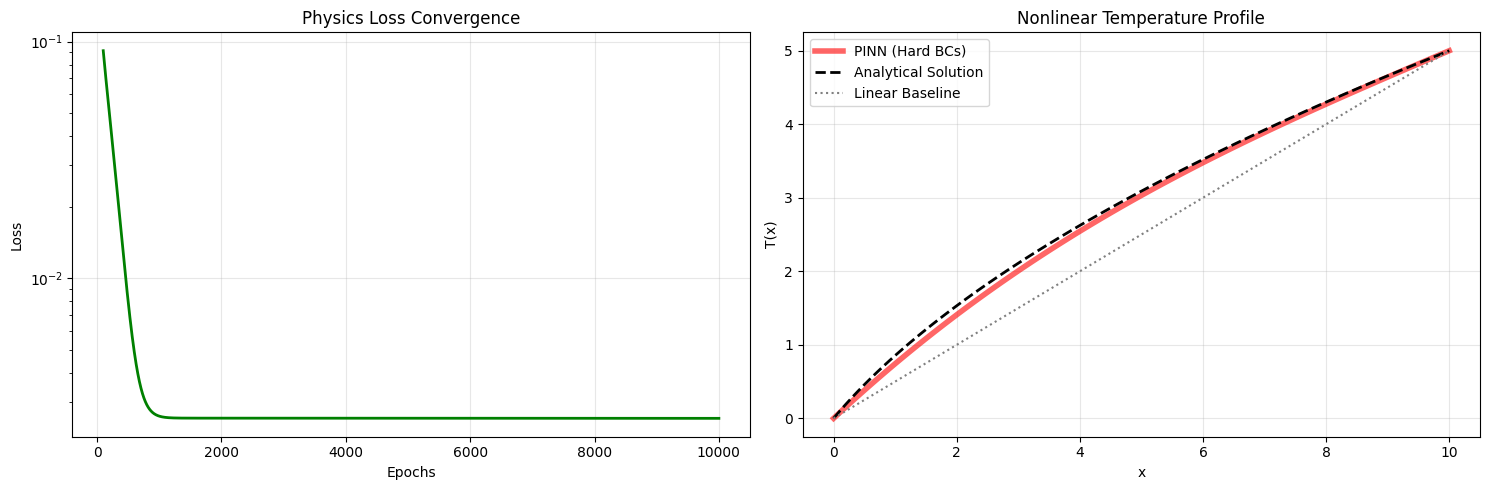

In [ ]:
# @title
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- 1. Physical Constants ---
L = 10.0
T_LEFT = 0.0
T_RIGHT = 5.0
K0 = 1.0
BETA = 0.4

# --- 2. Neural Network & Hard Constraint Transformation ---
def neural_net(params, x):
    W1, b1, W2, b2 = params
    x_scaled = x / L
    hidden = jnp.tanh(jnp.dot(x_scaled, W1) + b1)
    return jnp.dot(hidden, W2) + b2

def T_pred(params, x):
    # A. Boundary Term: Satisfies T(0)=0 and T(10)=5
    boundary_term = (T_RIGHT / L) * x

    # B. Shaping Function: Zero at both x=0 and x=10
    shaping_fn = x * (L - x)

    # C. Neural Network Output
    nn_out = neural_net(params, jnp.array([x]))[0]

    # D. Final Solution (Forced to satisfy BCs)
    return boundary_term + (shaping_fn * nn_out)

# --- 3. Pure Physics Loss Function ---
def loss_fn(params, x_physics):
    # Governing Eq: d/dx( k(T) * dT/dx ) = 0
    # No BC loss needed here because of the Hard Constraint above
    def get_residual(x):
        T = lambda v: T_pred(params, v)
        dT_dx = jax.grad(T)
        k_T = lambda v: K0 * (1.0 + BETA * T(v))
        flux = lambda v: k_T(v) * dT_dx(v)
        return jax.grad(flux)(x)

    physics_residuals = jax.vmap(get_residual)(x_physics)
    return jnp.mean(physics_residuals**2)

# --- 4. Training Loop (Fixed LR with Decay at 4000) ---
key = jax.random.PRNGKey(42)
params = [jax.random.normal(key, (1, 20)) * 0.2, jnp.zeros(20),
          jax.random.normal(key, (20, 1)) * 0.1, jnp.zeros(1)]

x_physics = jnp.linspace(0.0, L, 2000)
lr = 0.001
grad_fn = jax.jit(jax.value_and_grad(loss_fn))
history = []

print("Training Thermal PINN with Hard Constraints...")
for epoch in range(10001):

    loss, grads = grad_fn(params, x_physics)
    params = [p - lr * g for p, g in zip(params, grads)]
    history.append(loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Physics Loss: {loss:.6e}")

# --- 5. Analytical Solution & Visualization ---
c1 = (T_RIGHT + 0.5 * BETA * T_RIGHT**2) / L
x_test = jnp.linspace(0, L, 100)
T_analytical = (-1.0 + jnp.sqrt(1.0 + 2.0 * BETA * (c1 * x_test))) / BETA
T_pinn = jax.vmap(T_pred, in_axes=(None, 0))(params, x_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Convergence
ax1.plot(range(100, 10001), history[100:], color='green', linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Physics Loss Convergence")
ax1.grid(True, alpha=0.3)

# Plot B: Result
ax2.plot(x_test, T_pinn, 'r-', label="PINN (Hard BCs)", linewidth=4, alpha=0.6)
ax2.plot(x_test, T_analytical, 'k--', label="Analytical Solution", linewidth=2)
ax2.plot(x_test, 0.5 * x_test, ':', label="Linear Baseline", color='gray')
ax2.set_xlabel("x")
ax2.set_ylabel("T(x)")
ax2.set_title("Nonlinear Temperature Profile")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Benchmarking PINNs vs. Classical Numerical Methods (FDM & FEM)

In this section, we validate our **Physics-Informed Neural Network (PINN)** by comparing it against two industry-standard numerical methods and the exact analytical solution.

---

## 1. Finite Difference Method (FDM)
FDM is the simplest numerical technique. It discretizes the domain into a grid of points and replaces derivatives with algebraic approximations.
* **Mechanism:** It uses a central difference scheme to approximate the heat flux at midpoints between nodes.
* **Nonlinearity:** Since $k(T)$ is nonlinear, the resulting system of equations is also nonlinear. We solve this by minimizing the total squared residual of the discretized equations across the grid.



---

## 2. Finite Element Method (FEM)
FEM is the "gold standard" in structural and thermal engineering. It divides the rod into small "elements" and uses local basis functions.
* **Mechanism:** We use the **Galerkin Method** with linear elements. The code implements a **Newton-Raphson** iterative solver to handle the temperature-dependent conductivity ($k(T)$).
* **Integration:** It uses **2-Point Gauss Quadrature** to numerically integrate the stiffness matrix and residual vector within each element.



---

## 3. Comparison Logic (The "Why")
This benchmark highlights several key differences between the methods:

| Method | Discretization | Basis Functions | Handling Nonlinearity |
| :--- | :--- | :--- | :--- |
| **FDM** | Point-based (Grid) | None (Local diff) | Nonlinear Optimization |
| **FEM** | Element-based | Local Piecewise | Newton-Raphson Iteration |
| **PINN** | Mesh-free | Global (Neural Net) | Gradient Descent (Backprop) |

---

## 4. Visualization of Results
The final plot overlays four distinct solutions:
1. **Analytical (Black Line):** The ground truth "perfect" math solution.
2. **PINN (Red Dashed):** The neural network's continuous approximation.
3. **FDM (Blue Dots):** Discrete values predicted at specific grid points.
4. **FEM (Green X's):** Discrete values predicted at element nodes.

**Success Criteria:** If all markers and lines align, it proves that the PINN has successfully learned the nonlinear heat physics to the same level of accuracy as classical engineering tools.

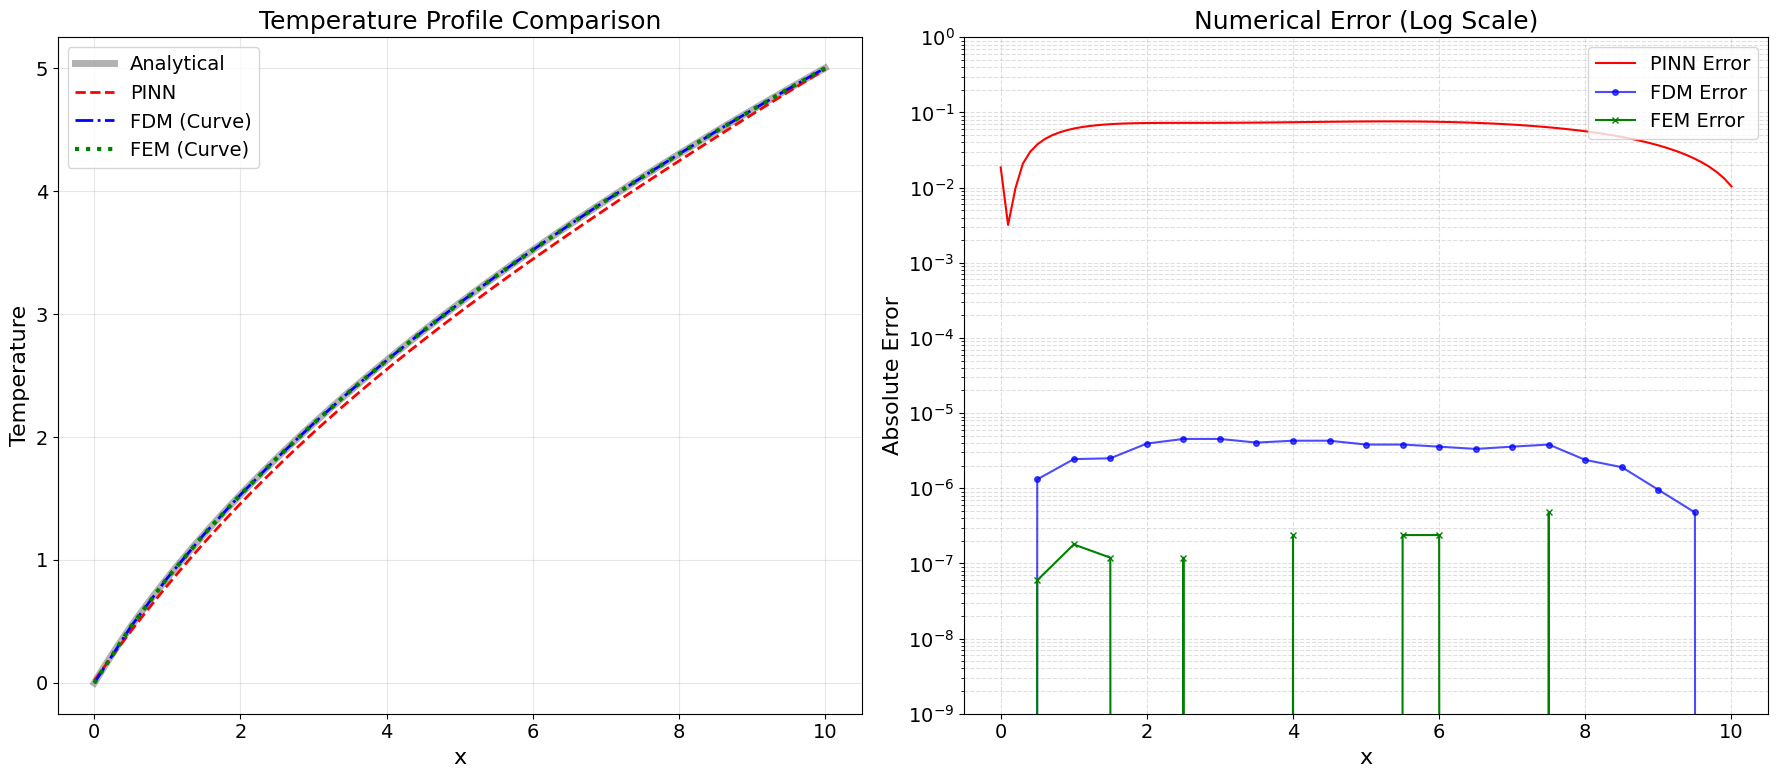

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Parameters & Boundary Conditions ---
L = 10.0
T_LEFT = 0.0
T_RIGHT = 5.0
K0 = 1.0
BETA = 0.4
N_ELEMENTS = 20

# --- 2. FDM Solver ---
def solve_fdm(n_points, l, tl, tr, k0, beta):
    dx = l / (n_points - 1)
    x_fdm = jnp.linspace(0, l, n_points)
    def residual(T_internal):
        T = jnp.concatenate([jnp.array([tl]), T_internal, jnp.array([tr])])
        T_mid_plus = (T[1:-1] + T[2:]) / 2.0
        T_mid_minus = (T[1:-1] + T[:-2]) / 2.0
        k_plus = k0 * (1.0 + beta * T_mid_plus)
        k_minus = k0 * (1.0 + beta * T_mid_minus)
        flux_diff = (k_plus * (T[2:] - T[1:-1]) / dx) - (k_minus * (T[1:-1] - T[:-2]) / dx)
        return jnp.sum(flux_diff**2)
    res = minimize(residual, jnp.linspace(tl, tr, n_points-2), method='BFGS')
    T_final = jnp.concatenate([jnp.array([tl]), res.x, jnp.array([tr])])
    return x_fdm, T_final

# --- 3. FEM Solver ---
def solve_fem(n_elements, l, tl, tr, k0, beta):
    nnodes = n_elements + 1
    le = l / n_elements
    x_fem = np.linspace(0, l, nnodes)
    T = np.linspace(tl, tr, nnodes)
    tol, max_iter = 1e-8, 20
    for iteration in range(max_iter):
        K_global, R_global = np.zeros((nnodes, nnodes)), np.zeros(nnodes)
        for e in range(n_elements):
            nodes = [e, e + 1]
            ke, re = np.zeros((2, 2)), np.zeros(2)
            for xi in [-1.0/np.sqrt(3), 1.0/np.sqrt(3)]:
                N = np.array([0.5 * (1 - xi), 0.5 * (1 + xi)])
                B = np.array([-0.5, 0.5]) / (le / 2.0)
                T_gp = N @ T[nodes]
                k = k0 * (1.0 + beta * T_gp)
                T_prime = B @ T[nodes]
                re += (B * k * T_prime) * (le / 2.0)
                ke += (np.outer(B, B) * k + np.outer(B, N) * (k0 * beta) * T_prime) * (le / 2.0)
            for i in range(2):
                R_global[nodes[i]] += re[i]
                for j in range(2): K_global[nodes[i], nodes[j]] += ke[i, j]
        free = np.arange(1, nnodes - 1)
        if np.linalg.norm(R_global[free]) < tol: break
        T[free] += np.linalg.solve(K_global[np.ix_(free, free)], -R_global[free])
    return jnp.array(x_fem), jnp.array(T)

# --- 4. PINN Logic ---
def neural_net(params, x):
    W1, b1, W2, b2 = params
    hidden = jnp.tanh(jnp.dot(x/L, W1) + b1)
    return jnp.dot(hidden, W2) + b2

def T_pred(params, x):
    return neural_net(params, jnp.array([x]))[0]

def loss_fn(params, x_phys):
    loss_bc = (T_pred(params, 0.0) - T_LEFT)**2 + (T_pred(params, L) - T_RIGHT)**2
    def get_res(x):
        T = lambda v: T_pred(params, v)
        dT_dx = jax.grad(T)
        flux = lambda v: K0 * (1.0 + BETA * T(v)) * dT_dx(v)
        return jax.grad(flux)(x)
    return 500.0 * loss_bc + 5000.0 * jnp.mean(jax.vmap(get_res)(x_phys)**2)

# --- 5. Training & Execution ---
x_fdm, T_fdm = solve_fdm(N_ELEMENTS + 1, L, T_LEFT, T_RIGHT, K0, BETA)
x_fem, T_fem = solve_fem(N_ELEMENTS, L, T_LEFT, T_RIGHT, K0, BETA)

key = jax.random.PRNGKey(42)
params = [jax.random.normal(key, (1, 20)) * 0.2, jnp.zeros(20),
          jax.random.normal(key, (20, 1)) * 0.1, jnp.zeros(1)]
grad_fn = jax.jit(jax.value_and_grad(loss_fn))
x_phys = jnp.linspace(0.0, L, 200)

for epoch in range(5001):
    loss, grads = grad_fn(params, x_phys)
    params = [p - 0.0001 * g for p, g in zip(params, grads)]

# --- 6. Data Prep ---
c1 = (T_RIGHT + 0.5 * BETA * T_RIGHT**2) / L
x_test = jnp.linspace(0, L, 100)
T_analytical = (-1.0 + jnp.sqrt(1.0 + 2.0 * BETA * (c1 * x_test))) / BETA
T_pinn = jax.vmap(T_pred, in_axes=(None, 0))(params, x_test)

err_pinn = jnp.abs(T_pinn - T_analytical)
err_fdm = jnp.abs(T_fdm - ((-1.0 + jnp.sqrt(1.0 + 2.0 * BETA * (c1 * x_fdm))) / BETA))
err_fem = jnp.abs(T_fem - ((-1.0 + jnp.sqrt(1.0 + 2.0 * BETA * (c1 * x_fem))) / BETA))

# --- 7. Plotting ---
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Main Profile: Curves only
ax1.plot(x_test, T_analytical, 'k-', label='Analytical', linewidth=5, alpha=0.3)
ax1.plot(x_test, T_pinn, 'r--', label='PINN', linewidth=2)
ax1.plot(x_fdm, T_fdm, 'b-.', label='FDM (Curve)', linewidth=2)
ax1.plot(x_fem, T_fem, 'g:', label='FEM (Curve)', linewidth=3)

ax1.set_title("Temperature Profile Comparison")
ax1.set_xlabel("x"); ax1.set_ylabel("Temperature")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Error Plot: Cleaned up curves
ax2.semilogy(x_test, err_pinn, 'r-', label='PINN Error')
ax2.semilogy(x_fdm, err_fdm, 'b-o', label='FDM Error', markersize=4, alpha=0.7)
ax2.semilogy(x_fem, err_fem, 'g-x', label='FEM Error', markersize=5)

# Limiting Y-axis to 1e-8 prevents the "spikes" from hitting the bottom zero
ax2.set_ylim(1e-9, 1e0)
ax2.set_title("Numerical Error (Log Scale)")
ax2.set_xlabel("x"); ax2.set_ylabel("Absolute Error")
ax2.legend(loc='upper right'); ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()